# Saguaro bud count data 2016 - 2026

## Load Data

In [22]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [23]:
# load bud count csv
df = pd.read_csv('Saguaro Bud Counts - Sheet1.csv')
df.head()

,Image,Year,Bud Count
0,15,2016,0
1,18,2016,9
2,19,2016,11
3,20,2016,51
4,21,2016,3


## Graph Data

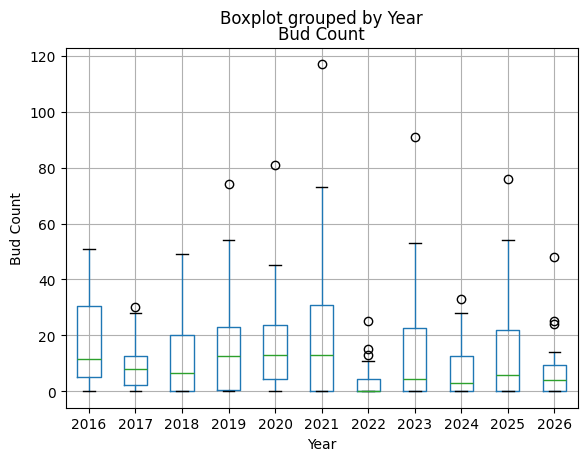

In [24]:
# box plot by year
df.boxplot(column='Bud Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.show()

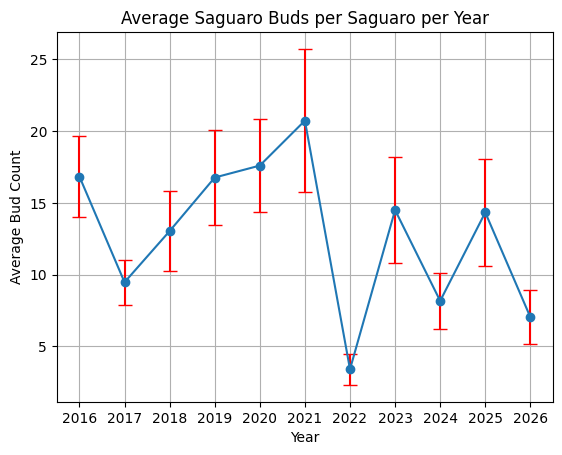

In [25]:
# line plot for mean each year with standard errors
yearly_buds_mean = df.groupby('Year')['Bud Count'].mean()
yearly_buds_se = df.groupby('Year')['Bud Count'].sem()

plt.errorbar(yearly_buds_mean.index, yearly_buds_mean.values, yerr=yearly_buds_se.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Saguaro per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

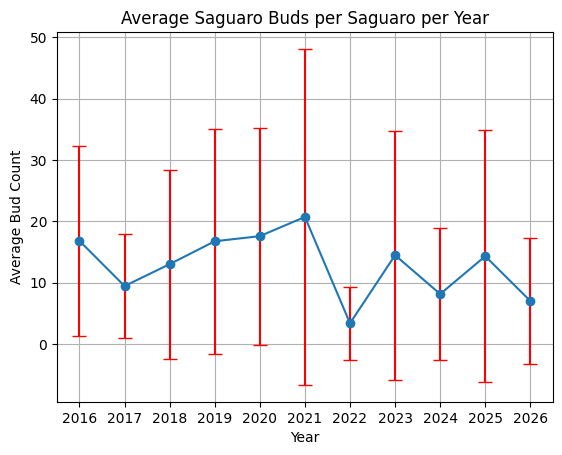

In [26]:
# line plot for mean each year with standard deviation
yearly_buds_std = df.groupby('Year')['Bud Count'].std()

plt.errorbar(yearly_buds_mean.index, yearly_buds_mean.values, yerr=yearly_buds_std.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Saguaro per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

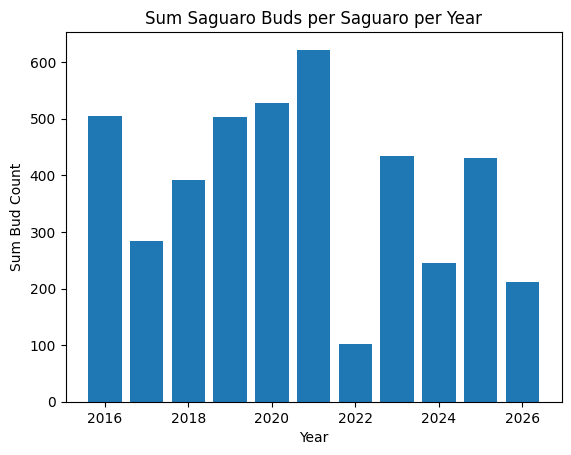

In [27]:
# bar plot for sums each year
yearly_buds_sum = df.groupby('Year')['Bud Count'].sum()

plt.bar(yearly_buds_sum.index, yearly_buds_sum.values)

plt.xlabel("Year")
plt.ylabel("Sum Bud Count")
plt.title("Sum Saguaro Buds per Saguaro per Year")
plt.show()

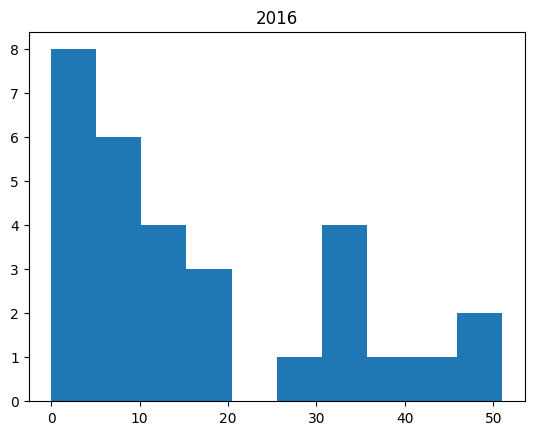

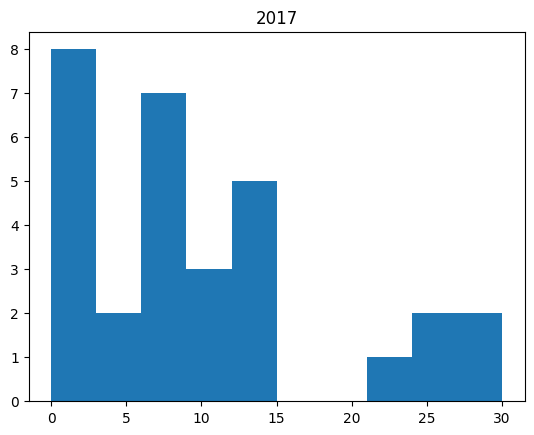

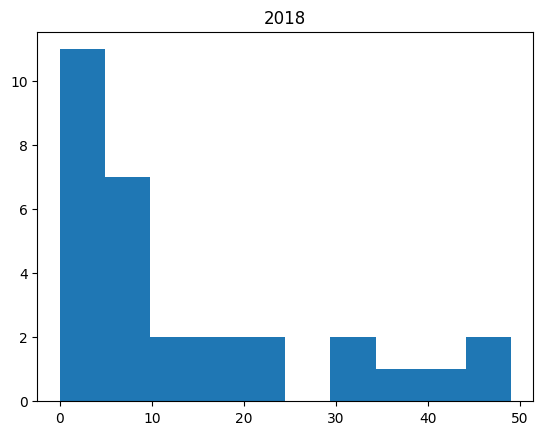

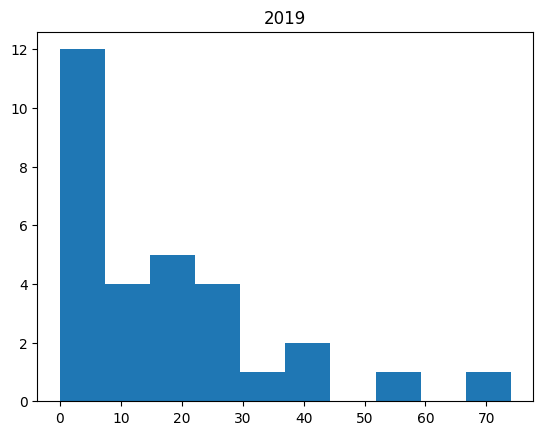

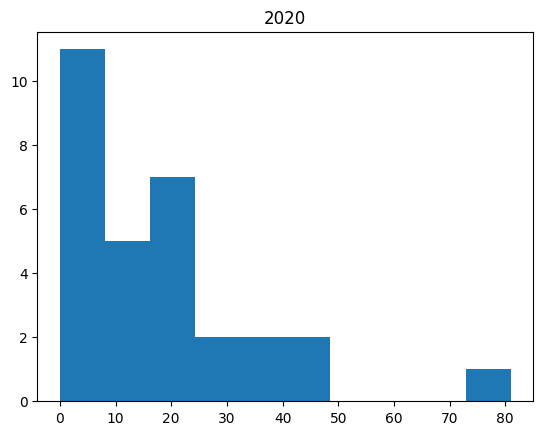

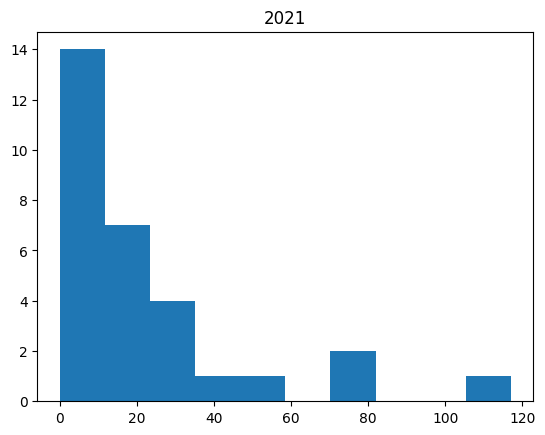

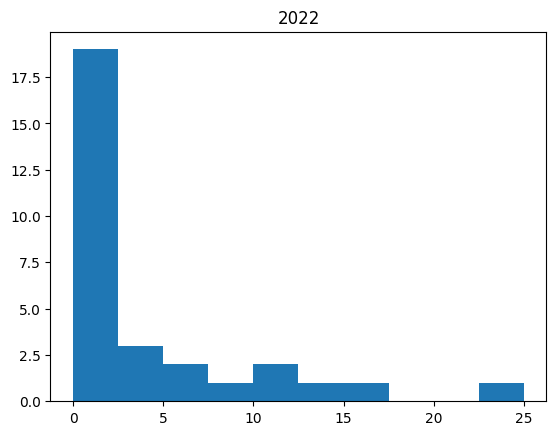

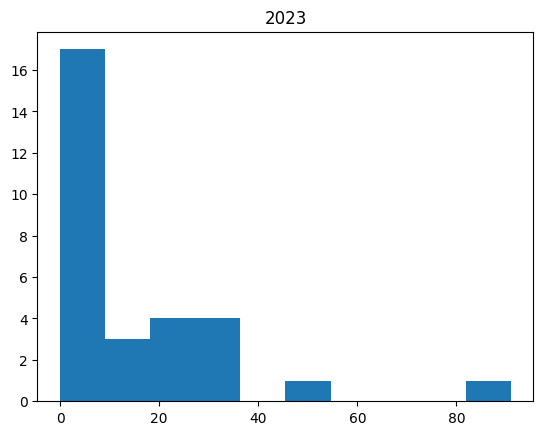

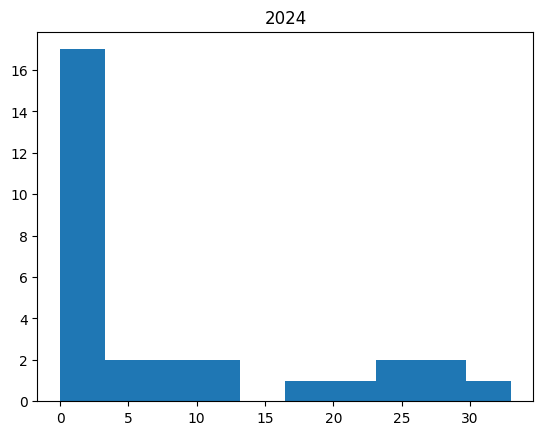

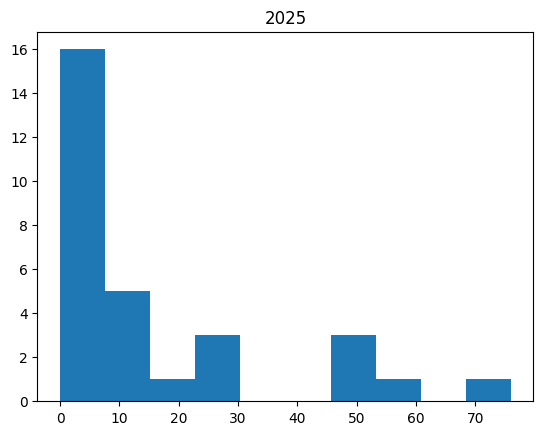

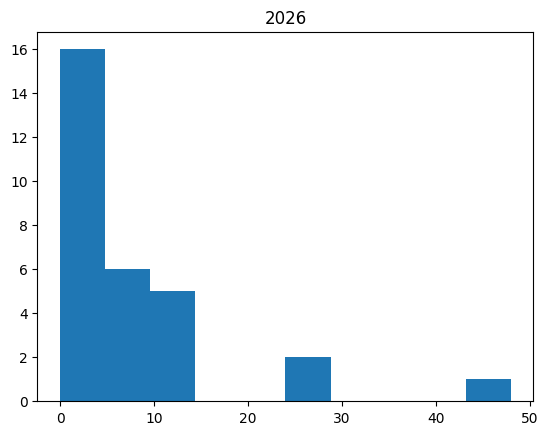

In [28]:
# make a histogram of each year 
for i in df.Year.unique():
    plt.hist(df[df['Year'] == i]['Bud Count'])
    plt.title(i)
    plt.show()

## Statistical Analysis

In [29]:
# check if anova test is valid
# check normality
model = LinearRegression()
model.fit(df[['Year']], df[['Bud Count']])

predictions = model.predict(df[['Year']])
residuals = df[['Bud Count']] - predictions

stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

# check homogeneity of variances
buds_2016 = df.loc[df['Year'] == 2016, 'Bud Count']
buds_2017 = df.loc[df['Year'] == 2017, 'Bud Count']
buds_2018 = df.loc[df['Year'] == 2018, 'Bud Count']
buds_2019 = df.loc[df['Year'] == 2019, 'Bud Count']
buds_2020 = df.loc[df['Year'] == 2020, 'Bud Count']
buds_2021 = df.loc[df['Year'] == 2021, 'Bud Count']
buds_2022 = df.loc[df['Year'] == 2022, 'Bud Count']
buds_2023 = df.loc[df['Year'] == 2023, 'Bud Count']
buds_2024 = df.loc[df['Year'] == 2024, 'Bud Count']
buds_2025 = df.loc[df['Year'] == 2025, 'Bud Count']
buds_2026 = df.loc[df['Year'] == 2026, 'Bud Count']
data = [buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026]

stat1, p1 = stats.levene(buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026)
print("Levene's p-value:", p1)

Shapiro-Wilk p-value: 3.0590918639177354e-21
Levene's p-value: 0.0004972388890877143


In [30]:
# since anova is not valid do kruskal wallis
h_stat, p2 = stats.kruskal(buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026)
print("H-statistic:", h_stat)
print("P-Value:", p2)

H-statistic: 31.43912535314998
P-Value: 0.0004963270782984553


In [31]:
# do dunns test
dunn_results = sp.posthoc_dunn(data, p_adjust='bonferroni')
print(dunn_results)

          1         2         3         4         5        6         7   \
1   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.001108   
2   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.200536   
3   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.264685   
4   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.018962   
5   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.002301   
6   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.023670   
7   0.001108  0.200536  0.264685  0.018962  0.002301  0.02367  1.000000   
8   1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.354168   
9   0.485416  1.000000  1.000000  1.000000  0.780305  1.00000  1.000000   
10  1.000000  1.000000  1.000000  1.000000  1.000000  1.00000  0.907840   
11  0.363864  1.000000  1.000000  1.000000  0.593587  1.00000  1.000000   

          8         9        10        11  
1   1.000000  0.485416  1.00000  0.363864  
2   1.00000

## Remove outliers

In [32]:
# get outliers
clean_data = []

for year in df['Year'].unique():
    year_data = df[df['Year'] == year]

    Q1 = year_data['Bud Count'].quantile(0.25)
    Q3 = year_data['Bud Count'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_year = year_data[
        (year_data['Bud Count'] >= lower) &
        (year_data['Bud Count'] <= upper)
    ]

    clean_data.append(clean_year)

df_no_outliers = pd.concat(clean_data)

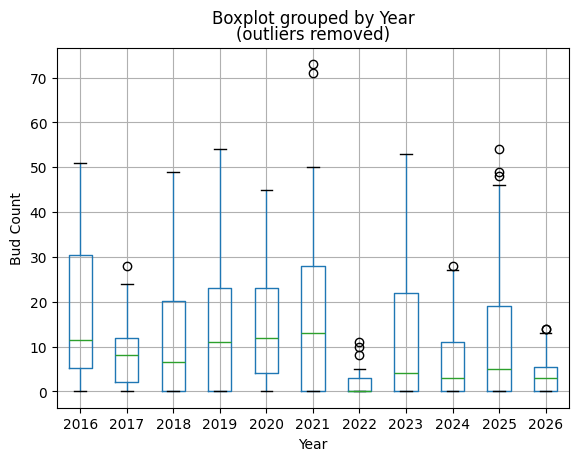

In [33]:
# box plot by year
df_no_outliers.boxplot(column='Bud Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.title("(outliers removed)")
plt.show()

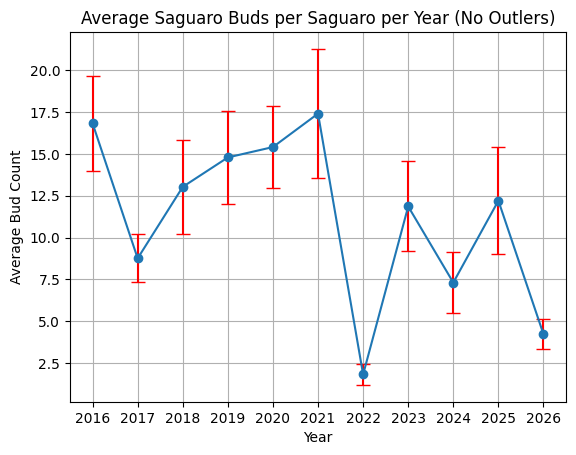

In [34]:
# line plot for mean each year with standard errors
yearly_buds_mean1 = df_no_outliers.groupby('Year')['Bud Count'].mean()
yearly_buds_se1 = df_no_outliers.groupby('Year')['Bud Count'].sem()

plt.errorbar(yearly_buds_mean1.index, yearly_buds_mean1.values, yerr=yearly_buds_se1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Saguaro per Year (No Outlers)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

In [35]:
# do anova test on all years without outliers
obuds_2016 = df_no_outliers.loc[df['Year'] == 2016, 'Bud Count']
obuds_2017 = df_no_outliers.loc[df['Year'] == 2017, 'Bud Count']
obuds_2018 = df_no_outliers.loc[df['Year'] == 2018, 'Bud Count']
obuds_2019 = df_no_outliers.loc[df['Year'] == 2019, 'Bud Count']
obuds_2020 = df_no_outliers.loc[df['Year'] == 2020, 'Bud Count']
obuds_2021 = df_no_outliers.loc[df['Year'] == 2021, 'Bud Count']
obuds_2022 = df_no_outliers.loc[df['Year'] == 2022, 'Bud Count']
obuds_2023 = df_no_outliers.loc[df['Year'] == 2023, 'Bud Count']
obuds_2024 = df_no_outliers.loc[df['Year'] == 2024, 'Bud Count']
obuds_2025 = df_no_outliers.loc[df['Year'] == 2025, 'Bud Count']
obuds_2026 = df_no_outliers.loc[df['Year'] == 2026, 'Bud Count']

data1 = [obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026]

f_stat1, p_val1 = stats.f_oneway(obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026)

print("f-statistic:", f_stat1)
print("p-value:", p_val1)

f-statistic: 4.000206150947237
p-value: 3.675571076609687e-05


In [36]:
# dunn test on data without outliers
dunn_results1 = sp.posthoc_dunn(data1, p_adjust='bonferroni')
print(dunn_results1)

          1         2         3         4         5         6         7   \
1   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.000056   
2   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.037761   
3   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.031198   
4   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.003763   
5   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.000346   
6   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.005367   
7   0.000056  0.037761  0.031198  0.003763  0.000346  0.005367  1.000000   
8   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.108495   
9   0.224422  1.000000  1.000000  1.000000  0.667015  1.000000  1.000000   
10  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  0.315709   
11  0.044679  1.000000  1.000000  0.777796  0.154334  0.982368  1.000000   

          8         9         10        11  
1   1.000000  0.224422  1.000000  0.044679

In [37]:
# do tukey test on all years without outliers
tukey1 = pairwise_tukeyhsd(endog=df_no_outliers['Bud Count'], groups=df_no_outliers['Year'], alpha=0.05)
print(tukey1)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  2016   2017  -8.0747 0.4505 -19.5617  3.4123  False
  2016   2018     -3.8 0.9919 -15.1893  7.5893  False
  2016   2019  -2.0402    1.0 -13.5273  9.4468  False
  2016   2020  -1.4195    1.0 -12.9066 10.0675  False
  2016   2021   0.5805    1.0 -10.9066 12.0675  False
  2016   2022 -15.0185  0.002 -26.7199 -3.3172   True
  2016   2023  -4.9713 0.9468 -16.4583  6.5158  False
  2016   2024   -9.523 0.2099   -21.01   1.964  False
  2016   2025  -4.6264 0.9673 -16.1135  6.8606  False
  2016   2026 -12.6111 0.0228 -24.3125 -0.9098   True
  2017   2018   4.2747 0.9814  -7.2123 15.7617  False
  2017   2019   6.0345   0.84  -5.5495 17.6185  False
  2017   2020   6.6552 0.7406  -4.9288 18.2391  False
  2017   2021   8.6552 0.3553  -2.9288 20.2391  False
  2017   2022  -6.9438  0.711 -18.7403  4.8527  False
  2017   2023   3.1034 0.998